In [1]:
import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Setup done")

Setup done


In [2]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

data = fetch_california_housing(as_frame=True)
df = data.frame

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (14448, 8)
Validation: (3096, 8)
Test: (3096, 8)


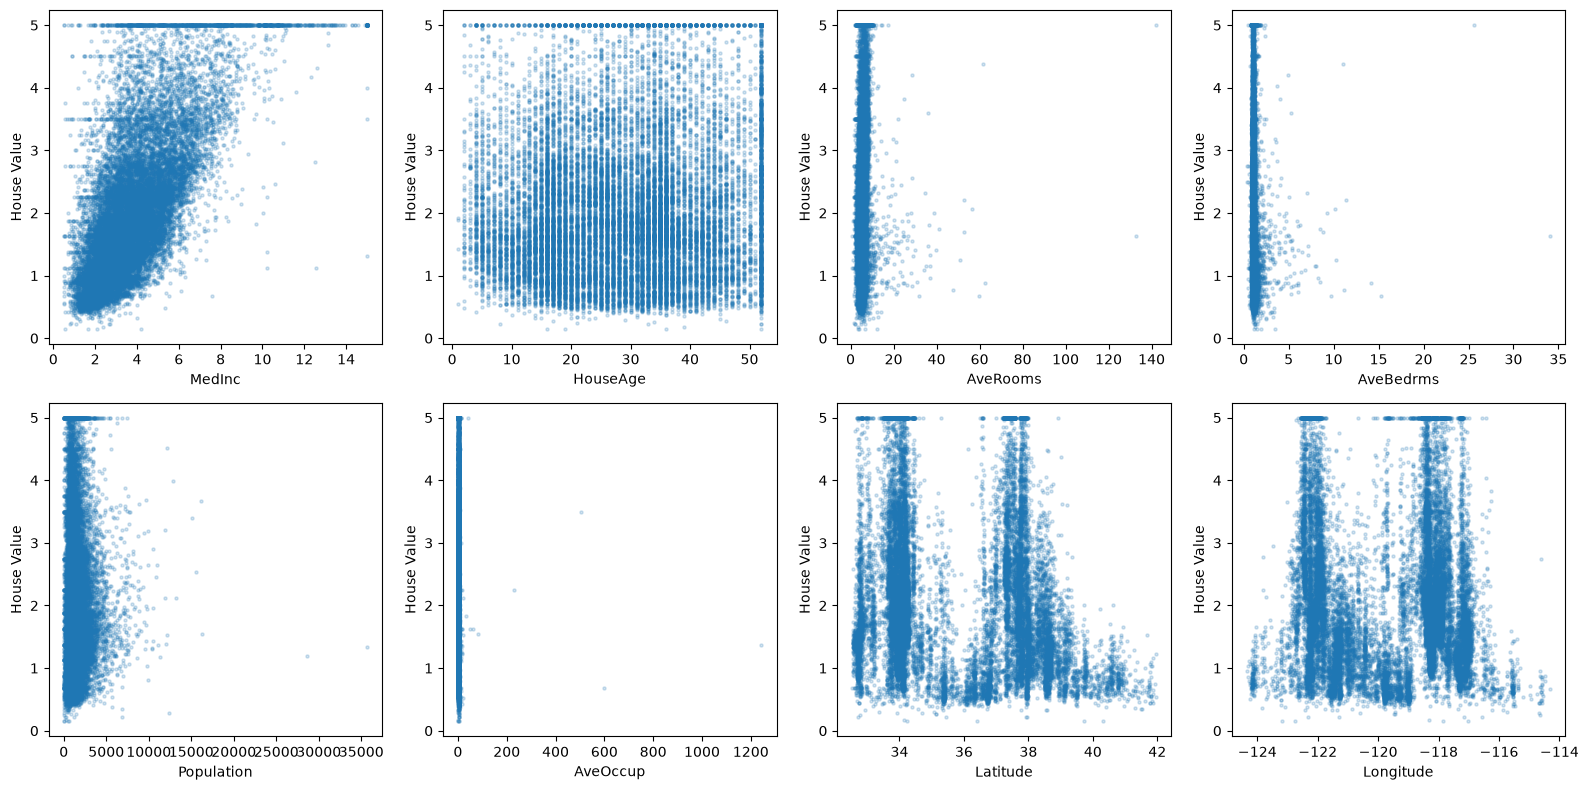

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].scatter(X[col], y, alpha=0.2, s=5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('House Value')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

baseline = LinearRegression()
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)
baseline_r2 = r2_score(y_val, baseline_pred)
baseline_rmse = mean_squared_error(y_val, baseline_pred) ** 0.5

print("Baseline Linear Regression")
print("R2:", baseline_r2)
print("RMSE:", baseline_rmse)

Baseline Linear Regression
R2: 0.5848261822866256
RMSE: 0.7354420909285341


In [6]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(random_state=SEED, n_estimators=200, max_depth=4, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)
xgb_r2 = r2_score(y_val, xgb_pred)
xgb_rmse = mean_squared_error(y_val, xgb_pred) ** 0.5

print("XGBoost")
print("R2:", xgb_r2)
print("RMSE:", xgb_rmse)

XGBoost
R2: 0.8147117636863884
RMSE: 0.491312062367586


In [7]:
train_pred = xgb_model.predict(X_train)
train_r2 = r2_score(y_train, train_pred)

print("Train R2:", train_r2)
print("Validation R2:", xgb_r2)

Train R2: 0.8699958826904597
Validation R2: 0.8147117636863884


In [8]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    xgb.XGBRegressor(random_state=SEED),
    params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

best_model = grid.best_estimator_
best_pred = best_model.predict(X_val)
print("Tuned Validation R2:", r2_score(y_val, best_pred))
print("Tuned Validation RMSE:", mean_squared_error(y_val, best_pred) ** 0.5)

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Tuned Validation R2: 0.8248699232769897
Tuned Validation RMSE: 0.4776544982514699


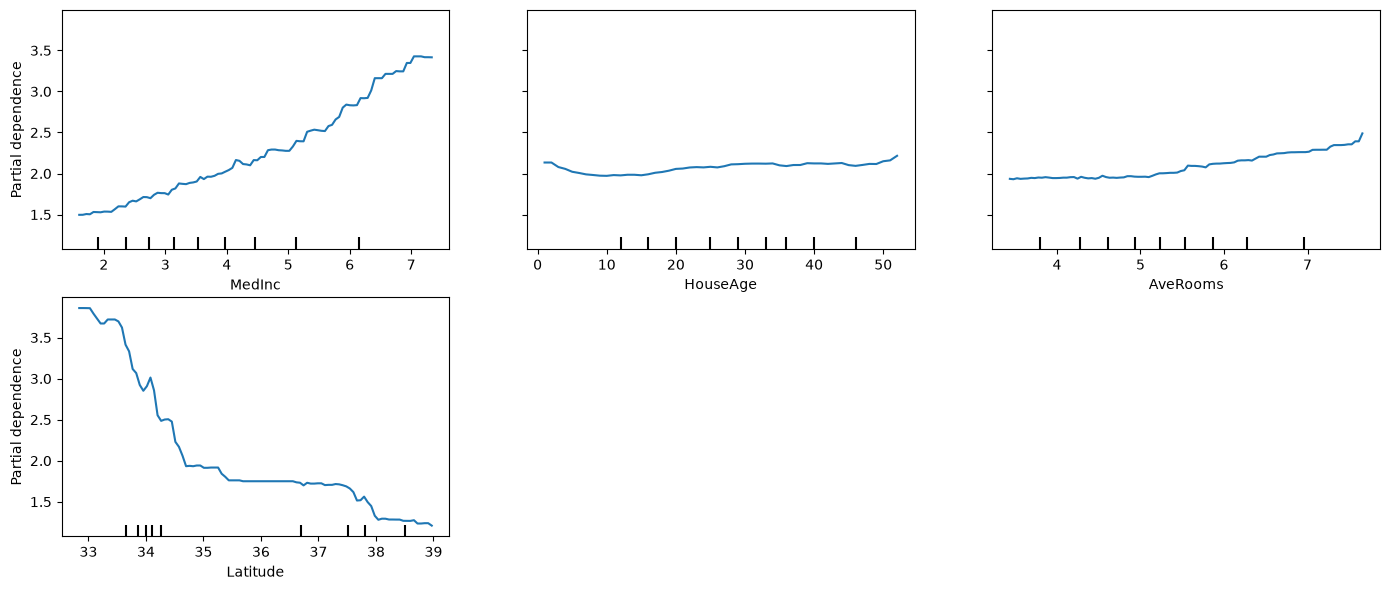

In [9]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(14, 6))
PartialDependenceDisplay.from_estimator(
    best_model, X_train, 
    features=['MedInc', 'HouseAge', 'AveRooms', 'Latitude'],
    ax=ax
)
plt.tight_layout()
plt.show()

In [10]:
test_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, test_pred)
test_rmse = mean_squared_error(y_test, test_pred) ** 0.5

print("Final Test R2:", test_r2)
print("Final Test RMSE:", test_rmse)

Final Test R2: 0.8476964977928992
Final Test RMSE: 0.4487677663968944


## Conclusion

- Baseline Linear Regression achieved R2 = 0.585 on validation.
- XGBoost (tuned) achieved R2 = 0.825 on validation and R2 = 0.848 on the held-out test set.
- Partial dependence plots showed sensible relationships (e.g. price rising with median income), confirming the model isn't overfitting to noise.
- The added complexity of XGBoost is justified: it captures non-linear relationships the linear baseline misses, producing a large, validated lift in performance.